# Telling models apart when the mean rate cannot

The mean crossing rate depends only on $r(0)$ and $r''(0)$. For the stochastic damped harmonic
oscillator these are fixed by the temperature and natural frequency, so **every damping ratio has
the same mean crossing rate**. The Fano factor depends on the whole covariance and can tell the
damping ratios apart.

Here we generate artificial data from an oscillator with a hidden damping ratio and recover it
from crossing counts alone.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch

from gaussian_crossings import GaussianCrossings, empirical_fano
from gaussian_crossings.process import r_damped_harmonic_oscillator_noise as oscillator
from gaussian_crossings.utils import simulate_gaussian_process_fft


def model(zeta):
    return GaussianCrossings(oscillator, temp=1.0, omega0=1.0, zeta=zeta)


levels = np.array([0.0, 0.5, 1.0, 1.5])
for zeta in [0.5, 1.0, 3.0]:
    print(f"zeta = {zeta}: mean rates {np.round(model(zeta).mean_rate(levels), 4)}, "
          f"long-time Fano {np.round(model(zeta).fano_factor(levels), 3)}")

zeta = 0.5: mean rates [0.1592 0.1405 0.0965 0.0517], long-time Fano [0.339 0.407 0.582 0.782]
zeta = 1.0: mean rates [0.1592 0.1405 0.0965 0.0517], long-time Fano [0.592 0.699 0.933 1.134]
zeta = 3.0: mean rates [0.1592 0.1405 0.0965 0.0517], long-time Fano [1.513 1.801 2.392 2.79 ]


## Artificial data with a hidden damping ratio

The velocity of this oscillator is rough, so the sampling step is kept small to avoid missing
crossings.

In [2]:
hidden_zeta = 1.5
dt, window = 0.02, 50.0

torch.manual_seed(7)
_, x = simulate_gaussian_process_fft(oscillator, 2e4, dt, temp=1.0, omega0=1.0, zeta=hidden_zeta)
data = empirical_fano(x.numpy(), levels, window=window, dt=dt, seed=0)

print("windows:", data.n_windows)
print("estimated mean rate per unit time:", np.round(data.mean / window, 4))
print("estimated Fano factor            :", np.round(data.fano, 3), "+/-", np.round(data.stderr, 3))

windows: 399
estimated mean rate per unit time: [0.1573 0.1386 0.0946 0.0503]
estimated Fano factor            : [0.883 0.923 1.321 1.699] +/- [0.073 0.067 0.097 0.154]


## Matching the Fano factor across damping ratios

For each candidate damping ratio, compute the finite-window prediction at the same thresholds
and window length, and score the mismatch with
$\chi^2(\zeta) = \sum_u [(\hat F_u - F_u(\zeta)) / \mathrm{se}_u]^2$.

estimated zeta = 1.55  (chi2 within 1 of the minimum: 1.50 to 1.60)
hidden zeta    = 1.5


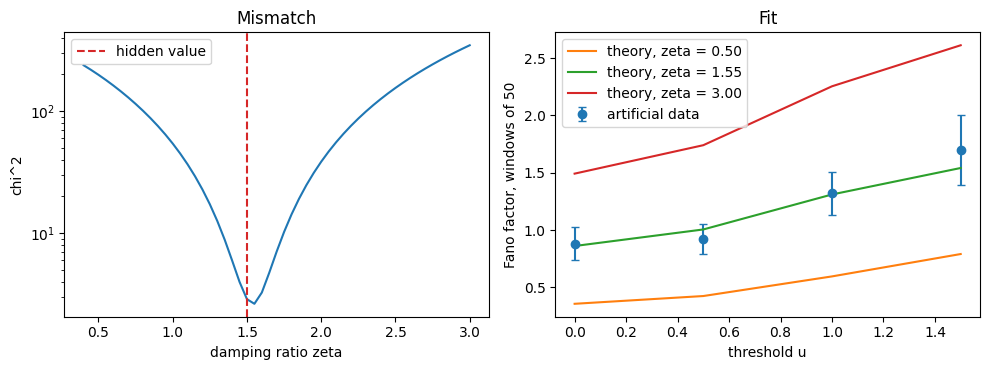

In [3]:
candidates = np.linspace(0.4, 3.0, 53)
predictions = np.array([model(z).fano_factor(levels, T=window) for z in candidates])
chi2 = (((data.fano - predictions) / data.stderr) ** 2).sum(axis=1)

best = candidates[np.argmin(chi2)]
plausible = candidates[chi2 <= chi2.min() + 1.0]
print(f"estimated zeta = {best:.2f}  (chi2 within 1 of the minimum: {plausible.min():.2f} to {plausible.max():.2f})")
print(f"hidden zeta    = {hidden_zeta}")

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))
left.plot(candidates, chi2)
left.axvline(hidden_zeta, color="tab:red", linestyle="--", label="hidden value")
left.set(xlabel="damping ratio zeta", ylabel="chi^2", yscale="log", title="Mismatch")
left.legend()
right.errorbar(levels, data.fano, yerr=1.96 * data.stderr, fmt="o", capsize=3, label="artificial data")
for zeta in [0.5, best, 3.0]:
    right.plot(levels, model(zeta).fano_factor(levels, T=window), label=f"theory, zeta = {zeta:.2f}")
right.set(xlabel="threshold u", ylabel=f"Fano factor, windows of {window:g}", title="Fit")
right.legend()
fig.tight_layout()

The mean rate is identical for every candidate, so it carries no information about the damping
ratio; the Fano factor pins it down.

This $\chi^2$ is a weighted mismatch score: it ignores the correlation between thresholds
(the same windows are used for all of them) and treats windows as independent. The reported
range whose score is within one unit of the minimum is descriptive, not a calibrated confidence
interval. Assess its coverage by repeating the full fitting procedure on many simulated datasets.